# Zadanie 3 – Efekt Aharonova-Bohma

Elektron przepływający przez pierścień kwantowy nabywa fazy $\phi_{\mathrm{AB}} = 2\pi\,\Phi/\Phi_0$, gdzie $\Phi = B_z\pi R^2$ to strumień przez pierścień, $\Phi_0 = h/e$ – kwant strumienia.

Różnica faz między górnym i dolnym ramieniem prowadzi do oscylacji konduktancji.

In [1]:
#importuje wszytskie potrzebne biblioteki w tym biblioteke kwant
import kwant
import numpy as np
import types
import matplotlib.pyplot as plt
      
    
#Obliczenia prowadze sa w jednostkach atomowych e=h=me=1. Tutaj definiuje wspolczynniki konwersji.
def eV2au(energy): #eV -> j.a
    return energy*0.03674932587122423
def nm2au(length): #nm -> j.a
    return length*18.89726133921252
def T2au(length):  #T -> j.a
    return length*4.254382E-6

/home/krzemon/Programming/Semestr_1/Symulacje nano-mezo/kwant_env/lib64/python3.13/site-packages/kwant/solvers/default.py:16: RuntimeWarning: MUMPS is not available, SciPy built-in solver will be used as a fallback. Performance can be very poor in this case.
  warnings.warn("MUMPS is not available, "


# Zdefiniowanie układu

In [2]:
############################################################################################
## W ramach zdefiniowania ukladu musimy zdefiniowac funkcje okreslajace energie potrzebne ##
## do przeskoku do tego samego wezla oraz wezlow sasiadujacych. Robimy to w funkcjach     ##
## onsite() oraz hopping_x() i hopping_y().
############################################################################################

#definicja ukladu do symulacji – pierscien kwantowy (efekt Aharonova-Bohma)
def make_system(nw):
    m=nw.m
    dx=nw.dx
    L=nw.L
    W=nw.W
    R1=nw.R1
    R2=nw.R2
    B=nw.B

    #strumien magnetyczny skupiony wewnatrz pierscienia (r < 0.9*R1)
    #faza AB zbierana jest w jednym przeskoku (ciecie pierscienia)
    phi = B * np.pi * (0.9 * R1 * dx)**2

    def is_lead(pos):
        (x, y) = pos
        return -W*dx/2 < y < W*dx/2

    def is_ring(pos):
        (x, y) = pos
        r2 = x**2 + y**2
        in_ring        = (R1*dx)**2 < r2 < (R2*dx)**2
        in_lead_region = r2 >= (R2*dx)**2 and is_lead(pos) and abs(x) < L/2*dx
        return in_ring or in_lead_region

    def onsite(site):
        (x, y) = site.pos
        t=1.0/(2.0*m*dx*dx)
        return 4*t

    def hopping_x(sitei, sitej):
        (xi, yi) = sitei.pos
        (xj, yj) = sitej.pos
        t=1.0/(2.0*m*dx*dx)        
        return -t
    
    def hopping_y(sitei, sitej):
         (xi, yi) = sitei.pos
         (xj, yj) = sitej.pos
         t=1.0/(2.0*m*dx*dx)
         return -t

    # W ramach definicji ukladu kolejno:
    # 1. Definujemy uklad - funkcja kwant.Builder()  
    # 2. Okreslamy geometrie siatki - kwant.lattice.square(dx, norbs=1)
    # 3. Uzupelniamy macierz – ksztalt pierscienia przez lat.shape()
    sys = kwant.Builder()  
    lat = kwant.lattice.square(dx, norbs=1)
    sys[lat.shape(is_ring, (0, int(R1+1)*dx))] = onsite
    sys[(kwant.builder.HoppingKind((-1,0), lat, lat))] = hopping_x
    sys[(kwant.builder.HoppingKind((0,-1), lat, lat))] = hopping_y

    #faza AB: jeden przeskok w dolnej polowie pierscienia zbiera caly strumien
    def hopping_x_phase(site1, site2):
        return hopping_x(site1, site2) * np.exp(1j * phi)

    def gains_phase(hop):
        ix, iy = hop[1].tag
        return iy < 0 and ix == 0

    sys[(hop for hop in kwant.builder.HoppingKind((-1,0), lat, lat)(sys)
         if gains_phase(hop))] = hopping_x_phase
    
    #dolaczam lewy kontakt do naszego ukladu
    lead_left = kwant.Builder(kwant.TranslationalSymmetry((-dx, 0)))    
    lead_left[lat.shape(is_lead, (0, 0))]=onsite
    lead_left[(kwant.builder.HoppingKind((-1,0), lat, lat))] = hopping_x
    lead_left[(kwant.builder.HoppingKind((0,-1), lat, lat))] = hopping_y
    sys.attach_lead(lead_left)
    
    #prawy kontakt jako lustrzane odbicie lewego
    sys.attach_lead(lead_left.reversed())
    
    #finalizujemy uklad
    sys = sys.finalized()
    return sys

# Zdefiniowanie funkcji do liczenia transportu

In [3]:
############################################################################################
##       Definiujemy rozne funkcje liczace podstawowe wlasnosci fizyczne                  ##
############################################################################################

#funkcja wyliczajaca relacje dyspersji w kontakcie nr_lead w granicach [-k_max,k_max] z nk punktami
def disperssion(nw, nr_lead, k_max, nk):
    dx=nw.dx
    sys=make_system(nw)
    momenta = np.linspace(-k_max*dx,k_max*dx,nk)
    bands=kwant.physics.Bands(sys.leads[nr_lead])
    energies=[bands(k) for k in momenta]
    return (momenta/dx)*nm2au(1.0), energies

#funkcja liczaca wspolczynnik transmisji przy zadanym polu B
def transmission(nw, E, B=None):
    if B is not None:
        nw.B = T2au(B)
    E=eV2au(E)
    sys=make_system(nw)
    smatrix=kwant.smatrix(sys,E)
    t=smatrix.transmission(1,0)
    return t

#funkcja rysujaca funkcje falowa elektronu o energii E wchodzacego do kontaku nr_lead
def wave_function(nw, E, nr_lead):
    E=eV2au(E)
    sys=make_system(nw)
    wave=kwant.wave_function(sys, E)
    density=(abs(wave(nr_lead))**2).sum(axis=0)
    kwant.plotter.map(sys,density)

#funkcja rysujaca prad elektronu o energii E wchodzacego do kontaku nr_lead w stanie nr_mod
def current(nw, E, nr_lead, nr_mod):
    E=eV2au(E)
    sys=make_system(nw)
    current = kwant.operator.Current(sys).bind()
    psi=kwant.wave_function(sys, E)(nr_lead)
    curr=current(psi[nr_mod])
    kwant.plotter.current(sys,curr)

# Definicja parametrów układu

In [4]:
inner_radius = 600   # R1 = 600 nm

nw = types.SimpleNamespace(\
                     dx=nm2au(1),
                     L=2500,
                     W=30,
                     m=0.014,
                     B=T2au(0),
                     R1=inner_radius,
                     R2=inner_radius + 30,
                       )

# Nasz układ

/home/krzemon/Programming/Semestr_1/Symulacje nano-mezo/kwant_env/lib64/python3.13/site-packages/kwant/_plotter.py:77: RuntimeWarning: plotly is not available, if other engines are unavailable, only iterator-providing functions will work
  warnings.warn("plotly is not available, if other engines are unavailable,"


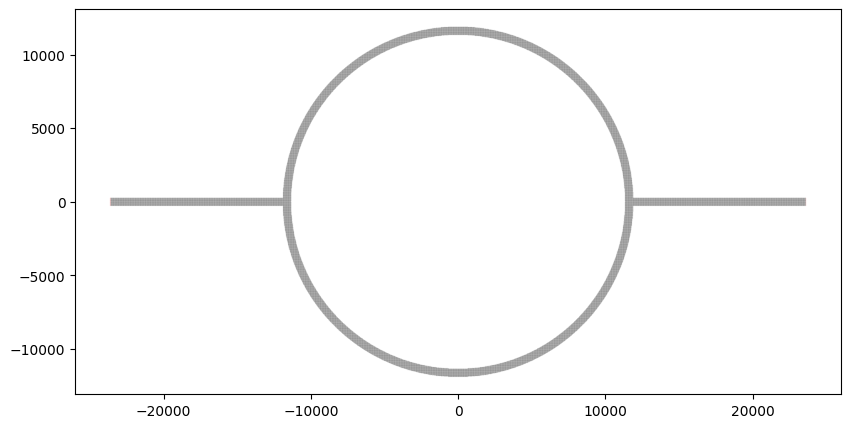

In [5]:
sys=make_system(nw)
kwant.plot(sys, site_color=lambda site: sys.hamiltonian(site,site), fig_size=(10,5), colorbar=False, show=False, num_lead_cells=2);

# Relacje dyspersji w lewym kontakcie

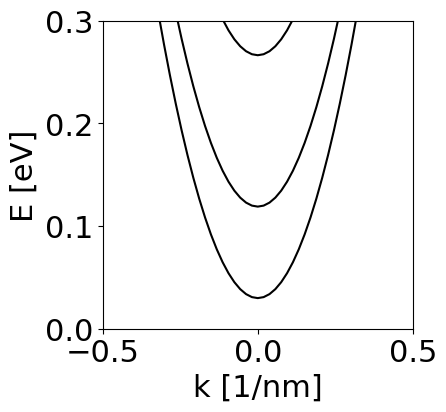

Energia najnizszego stanu poprzecznego: 0.0313 eV


In [6]:
momenta, energies = disperssion(nw, 0, .1, 201)
ene = np.asarray(energies)/eV2au(1.0)
plt.figure(figsize=(4,4))
plt.plot(momenta, ene,'k-')
plt.tick_params(axis='both', which='major', labelsize=22)
plt.ylim((0,.3))  
plt.xlim((-0.5,.5))  
plt.xlabel("k [1/nm]",fontsize=22)
plt.ylabel("E [eV]",fontsize=22)
plt.show()

lowest_E = float(np.min(ene)) * 1.05
print(f"Energia najnizszego stanu poprzecznego: {lowest_E:.4f} eV")

# Konduktancja w funkcji pola magnetycznego $G(B_z)$

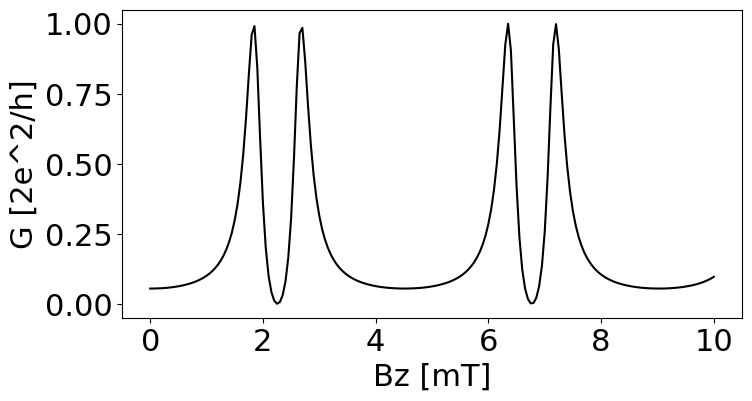

In [7]:
#konduktancja G(Bz) – oscylacje Aharonova-Bohma
#okres oscylacji: dBz = Phi_0 / (pi * R1^2) ~ 5.8 mT dla R1=600 nm
magnetic_fields = np.linspace(0, 10e-3, 201)
cond = [transmission(nw, lowest_E, B) for B in magnetic_fields]

plt.figure(figsize=(8,4))
plt.plot(magnetic_fields*1e3, cond,'k-')
plt.tick_params(axis='both', which='major', labelsize=22)
plt.xlabel("Bz [mT]",fontsize=22)
plt.ylabel("G [2e^2/h]",fontsize=22)
plt.show()

# Funkcje falowe i gęstości prądu

Minimum konduktancji – destruktywna interferencja

Bz_min = 2.25 mT


/tmp/ipykernel_23795/44128388.py:30: RuntimeWarning: The plotted data contains 0.45% of values overflowing upper limit 56.3764 
  kwant.plotter.map(sys,density)


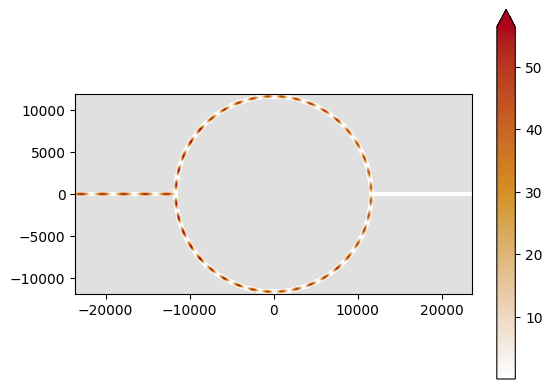

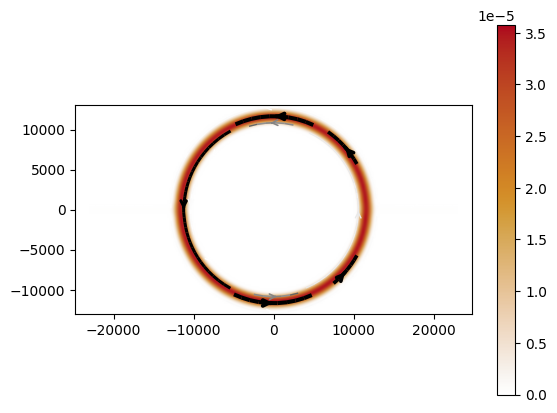

In [8]:
#pole odpowiadajace minimum konduktancji – destruktywna interferencja
B_min = magnetic_fields[np.argmin(cond)]
nw.B  = T2au(B_min)
print(f"Bz_min = {B_min*1e3:.2f} mT")
wave_function(nw, lowest_E, 0)
current(nw, lowest_E, 0, 0)

Maksimum konduktancji – konstruktywna interferencja

Bz_max = 6.35 mT


/tmp/ipykernel_23795/44128388.py:30: RuntimeWarning: The plotted data contains 0.89% of values overflowing upper limit 180.454 
  kwant.plotter.map(sys,density)


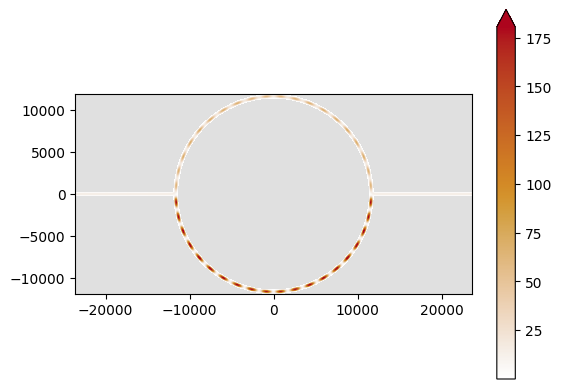

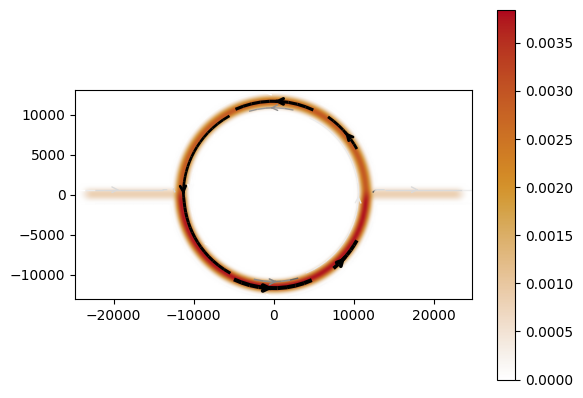

In [9]:
#pole odpowiadajace maksimum konduktancji – konstruktywna interferencja
B_max = magnetic_fields[np.argmax(cond)]
nw.B  = T2au(B_max)
print(f"Bz_max = {B_max*1e3:.2f} mT")
wave_function(nw, lowest_E, 0)
current(nw, lowest_E, 0, 0)